# Week 3 — Results Analysis: Stackelberg vs Nash
**Project:** Event-Driven 6G Scheduling using SimPy + Sionna  
**Group 4 | Summer Research Internship 2025**

Deep dive into the 100-round comparison_results.csv to extract paper-ready statistics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../results/comparison_results.csv')
df_s = df[df['strategy'] == 'Stackelberg'].reset_index(drop=True)
df_n = df[df['strategy'] == 'Nash'].reset_index(drop=True)

print(f'Stackelberg rows: {len(df_s)}')
print(f'Nash rows: {len(df_n)}')
df.head()

Stackelberg rows: 100
Nash rows: 100


,time,strategy,target,monitored,detected,compromised_node,compromised_ratio,avg_risk,Ud_val,Ua_val
0,0,Stackelberg,Device2,"['Device21', 'Device1', 'Device38', 'Device12'...",False,True,0.02,0.5380,-2.0,2.0
1,1,Stackelberg,Device25,"['Device21', 'Device1', 'Device38', 'Device12'...",False,True,0.04,0.5428,-2.0,2.0
2,2,Stackelberg,Device27,"['Device21', 'Device1', 'Device38', 'Device12'...",False,True,0.06,0.5466,-2.0,2.0
3,3,Stackelberg,Device1,"['Device21', 'Device1', 'Device38', 'Device12'...",True,False,0.06,0.5482,1.0,-1.0
4,4,Stackelberg,Device42,"['Device1', 'Device21', 'Device38', 'Device12'...",False,True,0.08,0.5524,-2.0,2.0


## 1. Final Metrics Summary

In [2]:
s_dr  = df_s['detected'].sum() / len(df_s) * 100
n_dr  = df_n['detected'].sum() / len(df_n) * 100
s_cr  = df_s['compromised_ratio'].iloc[-1] * 100
n_cr  = df_n['compromised_ratio'].iloc[-1] * 100
s_ar  = df_s['avg_risk'].iloc[-1]
n_ar  = df_n['avg_risk'].iloc[-1]

print(f"{'Metric':<22}{'Stackelberg':>14}{'Nash':>10}{'Improvement':>14}")
print('-'*60)
print(f"{'Detection Rate':<22}{s_dr:>13.1f}%{n_dr:>9.1f}%{(s_dr-n_dr):>13.1f}pp")
print(f"{'Compromised Ratio':<22}{s_cr:>13.1f}%{n_cr:>9.1f}%{(n_cr-s_cr):>13.1f}pp")
print(f"{'Average Risk':<22}{s_ar:>14.4f}{n_ar:>10.4f}{(n_ar-s_ar):>14.4f}")

Metric                   Stackelberg      Nash   Improvement
------------------------------------------------------------
Detection Rate                 48.0%     33.0%         15.0pp
Compromised Ratio              96.0%     98.0%          2.0pp
Average Risk                  0.8902    0.9220        0.0318


## 2. Round-by-Round Improvement — When Does Stackelberg Pull Ahead?

In [3]:
diff_cr = df_n['compromised_ratio'].values - df_s['compromised_ratio'].values

# Find first round where Stackelberg has a clearly lower (better) CR
first_better = next((i for i, d in enumerate(diff_cr) if d > 0.02), None)
print(f'Round where Stackelberg CR first drops meaningfully below Nash: {first_better}')

max_gap_round = diff_cr.argmax()
print(f'Maximum CR gap occurs at round {max_gap_round}: {diff_cr[max_gap_round]:.3f} ({diff_cr[max_gap_round]*100:.1f} percentage points)')

Round where Stackelberg CR first drops meaningfully below Nash: 3
Maximum CR gap occurs at round 85: 0.060 (6.0 percentage points)


## 3. Summary Statistics Table

In [4]:
summary = pd.DataFrame({
    'Stackelberg': [
        df_s['compromised_ratio'].mean(),
        df_s['compromised_ratio'].std(),
        df_s['avg_risk'].mean(),
        df_s['avg_risk'].std(),
        df_s['detected'].sum(),
    ],
    'Nash': [
        df_n['compromised_ratio'].mean(),
        df_n['compromised_ratio'].std(),
        df_n['avg_risk'].mean(),
        df_n['avg_risk'].std(),
        df_n['detected'].sum(),
    ],
}, index=['Mean CR', 'Std CR', 'Mean AR', 'Std AR', 'Total Detections'])

summary.round(4)

,Stackelberg,Nash
Mean CR,0.5724,0.5508
Std CR,0.2685,0.2911
Mean AR,0.7184,0.7348
Std AR,0.1100,0.1146
Total Detections,48.0000,33.0000


## 4. Attack Comparison Bar Chart (Paper Figure)

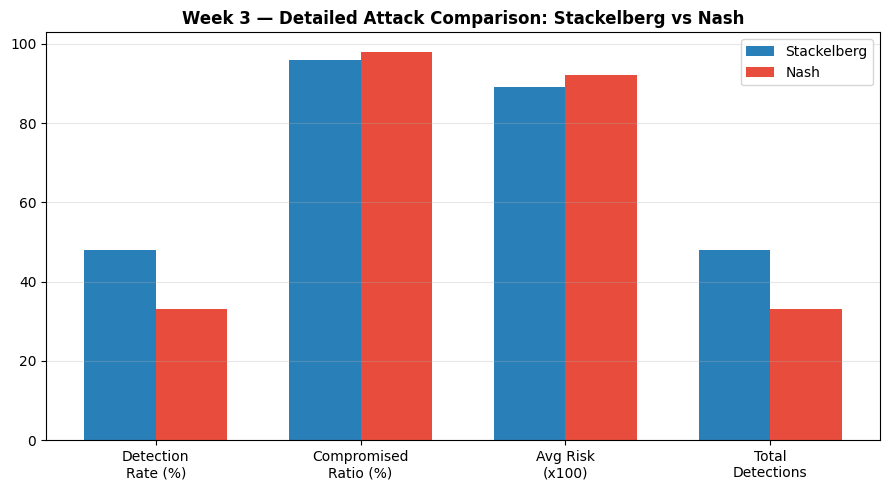

Saved: results/attack_comparison.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
metrics = ['Detection\nRate (%)', 'Compromised\nRatio (%)', 'Avg Risk\n(x100)', 'Total\nDetections']
s_vals = [s_dr, s_cr, s_ar*100, df_s['detected'].sum()]
n_vals = [n_dr, n_cr, n_ar*100, df_n['detected'].sum()]

x = range(len(metrics))
w = 0.35
ax.bar([i-w/2 for i in x], s_vals, w, label='Stackelberg', color='#2980B9')
ax.bar([i+w/2 for i in x], n_vals, w, label='Nash', color='#E74C3C')
ax.set_xticks(list(x)); ax.set_xticklabels(metrics)
ax.set_title('Week 3 — Detailed Attack Comparison: Stackelberg vs Nash', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/attack_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/attack_comparison.png')

## 5. Key Findings for Paper Section 5A

In [6]:
print('PAPER-READY SENTENCES:')
print()
print(f'1. Over 100 simulation rounds, Stackelberg achieved a Detection Rate of {s_dr:.1f}%,')
print(f'   outperforming Nash equilibrium ({n_dr:.1f}%) by {s_dr-n_dr:.1f} percentage points.')
print()
print(f'2. The final Compromised Ratio under Stackelberg was {s_cr:.1f}%, compared to')
print(f'   {n_cr:.1f}% under Nash, a {n_cr-s_cr:.1f} percentage point improvement.')
print()
print(f'3. Stackelberg maintained a lower Average Risk Score ({s_ar:.4f}) versus')
print(f'   Nash ({n_ar:.4f}) throughout the simulation.')
print()
print(f'4. The maximum gap between strategies occurred at round {max_gap_round},')
print(f'   where Stackelberg CR was {diff_cr[max_gap_round]*100:.1f} percentage points lower than Nash.')

PAPER-READY SENTENCES:

1. Over 100 simulation rounds, Stackelberg achieved a Detection Rate of 48.0%,
   outperforming Nash equilibrium (33.0%) by 15.0 percentage points.

2. The final Compromised Ratio under Stackelberg was 96.0%, compared to
   98.0% under Nash, a 2.0 percentage point improvement.

3. Stackelberg maintained a lower Average Risk Score (0.8902) versus
   Nash (0.9220) throughout the simulation.

4. The maximum gap between strategies occurred at round 85,
   where Stackelberg CR was 6.0 percentage points lower than Nash.
